In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, mean_squared_error, ConfusionMatrixDisplay

In [2]:
iris = datasets.load_iris()
X = iris.data[:,  :2]
y = iris.target


In [3]:
X =X[y !=2]
y =y[y != 2]

In [4]:
model = SVC(kernel='linear')
model.fit(X, y)

SVC(kernel='linear')

Matrix de confusion
conf


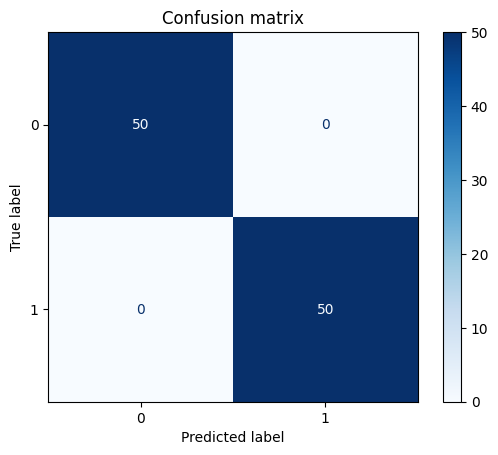

In [5]:
y_pred = model.predict(X)

conf = confusion_matrix(y, y_pred)
print('Matrix de confusion')
print("conf")

disp = ConfusionMatrixDisplay(confusion_matrix=conf, display_labels=model.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.title('Confusion matrix')
plt.show()

In [6]:
mse = mean_squared_error(y, y_pred)
print(f'Mean squared error:, {mse:.4f}')

Mean squared error:, 0.0000


In [7]:
#visualizacion: Regiones de decision (meshfrid, hiperplano, vectores)


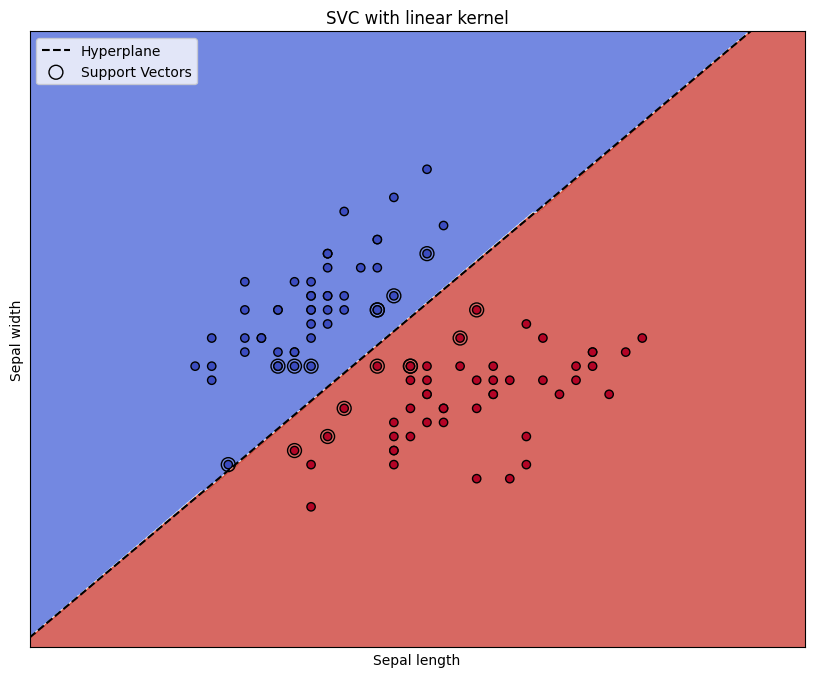

In [8]:
plt.figure(figsize=(10, 8))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = .02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')


w = model.coef_[0]
a = -w[0] / w[1]
x_hyperplane = np.linspace(x_min, x_max)
y_hyperplane = a * x_hyperplane - (model.intercept_[0]) / w[1]
plt.plot(x_hyperplane, y_hyperplane, 'k--', label='Hyperplane')

plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='k', marker='o', label='Support Vectors')

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.title('SVC with linear kernel')
plt.legend()
plt.show()